<a href="https://colab.research.google.com/github/jasreman8/Introduction-to-Agents/blob/main/CREWAI_Agents_Components.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Learning Objectives

- Understand the following key abstractions to implement generative AI agents using `crewai`:
    - Reasoning
    - Tools
    - Memory

# Setup

In [1]:
!pip install -q openai==1.66.3 \
                crewai==0.114.0 \
                langchain-community==0.3.19

In [2]:
import os

from crewai import LLM, Agent, Task, Crew, Process
from crewai.tools import tool #decorator used to convert a function into a usable "tool" that agents can call.
from crewai.memory import ShortTermMemory, EntityMemory #short-term memory --> recent conversatiosn or tasks, entity --> long-term info that agent encounters.
from crewai.memory.storage.rag_storage import RAGStorage #storage backend allowing agents to store and retrieve docs

from langchain_community.tools.tavily_search import TavilySearchResults

from google.colab import userdata

# CREWAI imports:
# Importing LLM --> for large language model management. It is the wrapper for LLM used by agents (defining temperature, model, etc.)
# Importing Agent --> for creating agent/AI persona (with role, goals, tools, memory and behavior)
# Importing Task --> for assigning work assignments (specific piece of work assigned to an agent)
# Importing Crew --> for orchestrating everything together (orchestrates multiple agents and tasks into a coordinated workflow)
# Importing Process --> Defines how tasks are executed - sequential, hierarchical, or parallel.

# Importing memory components to learn and train from interactions.
# CrewAI's memory system gives agents real-time context through short term memory.
# Setting up access to Tavily Search Results to serve as our agent's gateway to the current information on the internet.

In [3]:
openai_api_key = userdata.get('OPEN_API_KEY')

In [4]:
os.environ['TAVILY_API_KEY'] = userdata.get('tavily_search_api_key')

In [5]:
os.environ['OPENAI_API_KEY'] = openai_api_key
os.environ['OPENAI_API_BASE'] = "https://aibe.mygreatlearning.com/openai/v1"

In [6]:
llm = LLM(
    model='gpt-4o-mini',
    base_url="https://aibe.mygreatlearning.com/openai/v1",
    api_key=openai_api_key,
    temperature=0
)
# temperature is zero --> the model is going to be focused and deterministic in its responses.

# Business Objective

Develop an intelligent conversational agent capable of answering user queries accurately and effectively. The agent should leverage its internal knowledge but also dynamically access external, up-to-date information via web search (using Tavily Search) when necessary to provide comprehensive and current responses. This ensures users receive relevant answers even for topics beyond the agent's static training data, making it suitable for roles like research assistance, complex question answering, or providing current event summaries. The agent must maintain conversation history to understand context across multiple interactions.

# Implementation Plan

In this notebook, we implement a single-agent Crew designed to function as an expert research analyst. The goal is to take a user's query, understand its requirements, and provide a comprehensive answer. The implementation leverages CrewAI's core abstractions:

- Tool Definition: A specific tool (`tavily_search`) is defined using the @tool decorator, allowing the agent to perform external web searches via Tavily. This encapsulates the action/tool use capability.
- Agent Definition: An Agent (`researcher`) is configured with a specific role, goal, and backstory. These prompts, combined with the assigned LLM (`llm`), guide the agent's reasoning process - deciding how to approach the task and whether to use its assigned tool. The tool is explicitly linked to the agent. Memory capabilities are enabled.

- Task Definition: A Task (`research_task`) is created, providing a detailed description of the work the agent needs to perform based on the user's input. This description further shapes the agent's reasoning and clarifies the expected output.

- Memory Configuration: The Crew is explicitly configured with to store and retrieve relevant information from past interactions or extracted entities using vector embeddings.

- Crew Orchestration: A Crew object (`research_crew`) assembles the agent and task. It manages the execution flow (sequentially, in this case) and orchestrates the interplay between the agent's reasoning, tool use, and memory access to accomplish the task.
Execution: The `crew.kickoff()` method initiates the process, feeding the user input into the defined task and triggering the agent's execution cycle.

# Configuring a Search Tool

As an example we attach the Tavily Search API as a tool to our LLM.

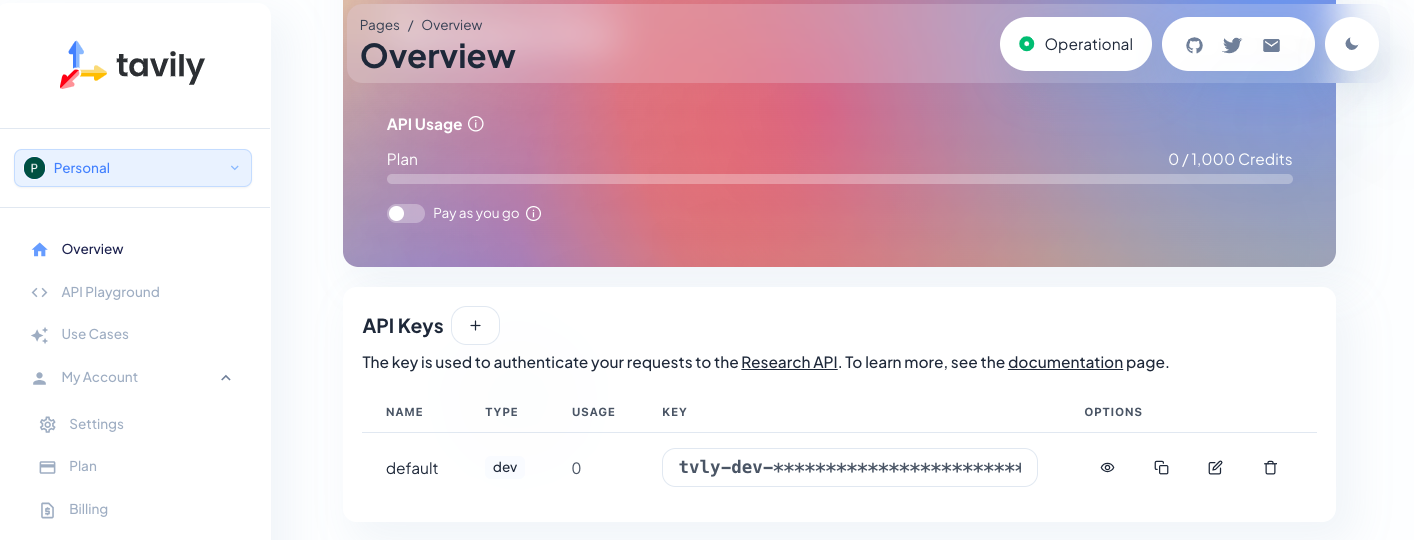

We will use the TavilySearchTool from LangChain but customize it to be compatible with Crew AI.

In [7]:
tavily_search_tool = TavilySearchResults(max_results=5)

# Tavily's search engine handles the entire process of searching, scraping, filtering, and extracting the most relevant...
# web information in one API call, reducing developer burden and complexity.

In [8]:
@tool("search_tool") #this decorator turns a normal Python function into a tool that agents can call during reasoning.
#Each time I mark a function with @tool it becomes a skill that the agent can use.
def tavily_search(query: str) -> str:
    """Search and return results using the Tavily search API"""
    final_output = ''

    for result in tavily_search_tool.invoke(query):
        final_output += result['content']

    return final_output
# Tavily can be integrated with LangChain, CrewAI, or custom AutoGen frameworks by registering the search function ...
# and allowing agents to invoke it dynamically.

The above code block defines the tool the agent can use.
- First, an instance of the LangChain TavilySearchResults tool is created (`tavily_search_tool`).
- Then, a standard Python function `tavily_search` is defined. This function takes a query string, uses the `tavily_search_tool` instance to perform the search (`invoke`), processes the list of dictionary results to concatenate the 'content' into a single string (`final_output`), and returns that string.

CrewAI Abstraction (`@tool("search_tool")`): The `@tool` decorator is crucial. It registers the tavily_search Python function as a tool usable by CrewAI agents.

- The string "search_tool" passed to the decorator becomes the name the LLM will use when it decides to call this tool.

- The function's docstring ("""Search and return...""") serves as the description provided to the LLM, explaining what the tool does.
- The function's type hints (query: str -> str) inform the LLM about the expected input and output types.

In this way, this above code block illustrates the capability to use custom tools with the agent within Crew AI.

# Assembling the Agent and Crew

Let us now define a single agent in our crew. In Crew AI, the `Agent` class represents an autonomous unit with specific capabilities and objectives. Let us look at the key parameters of the `Agent` class defined below:

- `role`, `goal`, `backstory`: These parameters are essentially prompts that define the agent's persona, objectives, and operational guidelines. They heavily influence the LLM's reasoning process when this agent is active. The LLM uses this context to decide how to approach the task and whether using a tool is appropriate.

- `verbose=True`: Enables detailed logging of the agent's thought process and actions during execution, useful for debugging and understanding its reasoning.

- `allow_delegation=False`: Specifies that this agent cannot delegate tasks to other agents (relevant in multi-agent crews).

- `tools=[tavily_search]`: Assigns the list of available tools (our decorated tavily_search function) to this specific agent. This directly links the Tool Use capability.

- `llm=llm`: Assigns the configured LLM instance to this agent, specifying the engine for its reasoning.

- `memory=True`: Enables the agent's built-in memory capabilities. While more specific memory is configured on the Crew, this flag often signals the agent itself should be memory-aware.

In [9]:
researcher = Agent(
  role='Expert Research Analyst',
  goal='Analyze the user query, determine if external information is needed, use the search tool to find relevant, up-to-date information, and synthesize a comprehensive answer.',
  backstory=(
    "You are a skilled analyst with expertise in synthesizing information. "
    "You critically evaluate user queries to understand the core information need. "
    "If the query requires knowledge beyond your internal data, especially regarding recent events or specific data points, "
    "you proactively use the Tavily search tool to gather necessary facts. "
    "You then integrate the search results coherently into your final answer."
  ),
  verbose=True, # Enable verbose output to see agent's reasoning and tool use
  allow_delegation=False, # This agent works alone for this task
  tools=[tavily_search], # Assign the tool(s) to the agent
  llm=llm, # Assign the specific LLM configuration for reasoning
  memory=True # Enable memory for the agent to potentially recall context from past interactions within the same crew execution (or longer-term if configured)
)

The code block below defines the specific job the researcher agent needs to perform. In Crew AI, the `Task` class encapsulates a unit of work. Key parameters to be defined for the `Task` class are:

- `description`: Provides detailed instructions for the agent. The {user_query} placeholder allows dynamic input injection during execution. This description is critical for guiding the agent's reasoning, explicitly telling it to analyze, consider tool use, synthesize, and respond.
- `expected_output`: Describes the desired format and quality of the task's final result. This helps the agent refine its output and focus its reasoning towards achieving the goal.
- `agent=researcher`: Assigns this specific task to the researcher agent.

In [10]:
research_task = Task(
  description=(
    "User Query: '{user_query}'.\n"
    "--- \n"
    "Analyze this query carefully. Determine if current information from the web is needed. "
    "If yes, use the search tool with an appropriate search term derived from the query. "
    "Synthesize the gathered information (if any) with your internal knowledge "
    "to provide a clear, accurate, and comprehensive answer directly addressing the user's query."
  ),
  expected_output=(
    "A final, synthesized answer to the user's query, integrating search results "
    "naturally if the search tool was used. The answer should be directly responsive "
    "to the original query and well-supported by facts."
  ),
  agent=researcher # Assign the task to our researcher agent (which was created in the previous cell)
)

The task description and expected output are the two most important aspects of the agent workflow defined with Crew AI.

In [11]:
research_crew = Crew(
  agents=[researcher],
  tasks=[research_task],
  process=Process.sequential, # Defines the execution order of tasks
  verbose=True, # sets the logging level for crew's orchestration process
  memory=True,
  short_term_memory=ShortTermMemory(
      storage=RAGStorage(
          type="short_term",
          path='./short-term-memory',
          embedder_config={
              "provider": "openai",
              "config": {
                  "model": 'text-embedding-3-small',
                  "api_key": openai_api_key,
                  "api_base": "https://aibe.mygreatlearning.com/openai/v1"
              }
          }
        )
    ),
  entity_memory=EntityMemory(
      storage=RAGStorage(
          type="short_term",
          path='./entity-memory',
          embedder_config={
              "provider": "openai",
              "config": {
                  "model": 'text-embedding-3-small',
                  "api_key": openai_api_key,
                  "api_base": "https://aibe.mygreatlearning.com/openai/v1"
              }
          }
        )
    )
)

The above code assembles the defined agent(s) and task(s) into an operational crew and configures its overall behavior and memory systems.

The main orchestrator class in Crew AI is `Crew`.

- `agents=[researcher], tasks=[research_task]`: Specifies the members of the crew and the work to be done.
- `process=Process.sequential`: Defines the task execution order. For a single task, this is straightforward, but for multiple tasks, it means they run one after another.
- `verbose=True`: Sets the logging level for the crew's orchestration process.
- `memory=True`: Enables memory features at the crew level, facilitating context sharing between tasks (if multiple existed).
- `short_term_memory=ShortTermMemory(...), entity_memory=EntityMemory(...)`: These explicitly configure the Memory subsystems for the crew.
    - `ShortTermMemory`: Designed to hold recent interaction context.
    - `EntityMemory`: Designed to extract and store information about key entities mentioned.
    - `RAGStorage`: Specifies that both memory types will use a Retrieval-Augmented Generation storage backend. This means memory items (chunks of text, entities) are embedded into vectors and stored. Retrieving relevant memories involves embedding a query and performing a vector similarity search. This is a more advanced memory mechanism than simple chat history logging. The embedder_config specifies the OpenAI embedding model (text-embedding-3-small) and API details to use.

# Task Execution

In [12]:
user_input = "Synthesize the impact of the recent US tariff rules on bond yields."

In [13]:
# Prepare the inputs for the task (matching the variable in the task description)
inputs = {'user_query': user_input}

# Start the crew's work!
print("\n--- Kicking off Crew ---")
result = research_crew.kickoff(inputs=inputs)
print("\n--- Crew Execution Complete ---")


--- Kicking off Crew ---


╭──────────────────────────────────────────── Crew Execution Started ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 5cf3cf5f-7abc-48d2-b771-28305c6b33c0                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

🚀 Crew: crew
└── 📋 Task: 48a712d6-c067-4d67-8a7f-ff752b61740d
       Status: Executing Task...

🚀 Crew: crew
└── 📋 Task: 48a712d6-c067-4d67-8a7f-ff752b61740d
       Status: Executing Task...
    └── 🤖 Agent: Expert Research Analyst
            Status: In Progress

# Agent: Expert Research Analyst
## Task: User Query: 'Synthesize the impact of the recent US tariff rules on bond yields.'.
--- 
Analyze this query carefully. Determine if current information from the web is needed. If yes, use the search tool with an appropriate search term derived from the query. Synthesize the gathered information (if any) with your internal knowledge to provide a clear, accurate, and comprehensive answer directly addressing the user's query.


...

🚀 Crew: crew
└── 📋 Task: 48a712d6-c067-4d67-8a7f-ff752b61740d
       Status: Executing Task...
    └── 🤖 Agent: Expert Research Analyst
            Status: ✅ Completed

🚀 Crew: crew
└── 📋 Task: 48a712d6-c067-4d67-8a7f-ff752b61740d
       Assigned to: Expert Research Analyst
       Status: ✅ Completed
    └── 🤖 Agent: Expert Research Analyst
            Status: ✅ Completed

╭──────────────────────────────────────────────── Task Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: 48a712d6-c067-4d67-8a7f-ff752b61740d                                                                     │
│  Agent: Expert Research Analyst                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 5cf3cf5f-7abc-48d2-b771-28305c6b33c0                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


--- Crew Execution Complete ---


In [14]:
# Print the final result from the crew's execution
print("\nFinal Answer:")
print(result)


Final Answer:
The recent US tariff rules have significantly impacted bond yields, primarily through their effects on inflation and economic growth. As tariffs have been implemented, they have contributed to rising input costs for many goods, which in turn has heightened inflation expectations. Economists suggest that these tariffs could add approximately 0.2 to 0.4 percentage points to the Personal Consumption Expenditures (PCE) price level, indicating a potential increase in inflation. This inflationary pressure may lead the Federal Reserve to adopt a more cautious approach regarding interest rate cuts, thereby influencing bond yields.

In the current economic climate, the benchmark 10-year US Treasury yield recently climbed above 4.5%, reflecting concerns over inflation and the broader economic implications of tariff policies. The Federal Reserve's actions, particularly in response to inflation and labor market conditions, have also played a crucial role in shaping bond yields. For 

The above code block initiates the crew's work.
- The `user_input` is defined.
- An `inputs` dictionary is created, mapping the placeholder variable name used in the `Task` description (`user_query`) to the actual user input value.

The `research_crew.kickoff(inputs=inputs)` method starts the execution. CrewAI manages the process:
- Passes the inputs to the first task (`research_task`).
- Activates the assigned agent (`researcher`).
- The agent's LLM uses its prompts (`role`, `goal`, `backstory`, task description) for reasoning.
- If reasoning dictates tool use, CrewAI intercepts, executes the assigned `@tool` function (`tavily_search`), leveraging the Tool Use mechanism.
- Results are fed back into the agent's context.
- Memory systems (`ShortTermMemory`, `EntityMemory`) are updated and queried during the process based on the Memory configuration.
- The agent continues reasoning until the task's `expected_output` is achieved.
- The final result of the last task is returned by kickoff.

In [15]:
research_crew.calculate_usage_metrics()

UsageMetrics(total_tokens=4138, prompt_tokens=3642, cached_prompt_tokens=0, completion_tokens=496, successful_requests=2)

# Inspecting Memory

Since the short-term memory and entity-memory maintained by the crew are Chroma vector databases under the hood, they can be inspected and searched.

For example, the `.short_term_memory.search('bonds')` and `.entity_memory.search('bonds')` methods directly query the configured Memory stores. They embed the search term ('bonds') using the configured embedder and perform a similarity search within the respective RAGStorage backends, returning relevant stored memory snippets related to the term. This allows introspection into what the agent remembered or extracted during its execution.

In [16]:
research_crew.short_term_memory.search('bonds')

[{'id': '316fd664-3074-459a-bce7-c456d63b556f',
  'metadata': {'agent': 'Expert Research Analyst',
   'observation': "User Query: 'Synthesize the impact of the recent US tariff rules on bond yields.'.\n--- \nAnalyze this query carefully. Determine if current information from the web is needed. If yes, use the search tool with an appropriate search term derived from the query. Synthesize the gathered information (if any) with your internal knowledge to provide a clear, accurate, and comprehensive answer directly addressing the user's query."},
  'context': "Thought: I have gathered relevant information regarding the impact of recent US tariff rules on bond yields. The data indicates that tariffs can influence inflation and economic growth, which in turn affects bond yields. I will now synthesize this information into a comprehensive answer.\n\nFinal Answer: The recent US tariff rules have significantly impacted bond yields, primarily through their effects on inflation and economic growt

In [17]:
research_crew.entity_memory.search('bonds')

[{'id': 'd44caa23-0985-47d1-b3d8-1938389f2764',
  'metadata': {'relationships': '- Impacted by tariffs\n- Correlated with inflation and economic growth\n- Influenced by Federal Reserve policies'},
  'context': 'bond yields(Finance): The return an investor realizes on a bond, affected by economic factors and monetary policy.',
  'score': 0.5574861764907837},
 {'id': '3f58eabc-6dfe-4b10-aabc-95fa2e96bea0',
  'metadata': {'relationships': '- affected by inflation\n- shaped by Federal Reserve actions\n- linked to fiscal policies'},
  'context': 'bond yields(Financial Metric): The return an investor can expect to earn on a bond, influenced by market conditions and policy changes.',
  'score': 0.5719935894012451},
 {'id': 'afb783d6-229e-4522-8244-8834319349c7',
  'metadata': {'relationships': '- Affected by tariffs\n- Displays investor expectations on long-term economic conditions'},
  'context': '30-year Treasury yield(Financial Metric): The return on investment for a US government bond tha